In [1]:
import torch
import os.path
import argparse
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from data import *
from utils import *
from PIL import Image
from datetime import datetime
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import train_test_split

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=100, help='Total # of samples')
parser.add_argument('--mb_size', type=int, default=100, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=10, help='Dim of latent vector')
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')
parser.add_argument('--x_fdim', type=int, default=128, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=20, help='Input y_fdim. See utils.py')
parser.add_argument('--c_accu', type=float, default=100, help='Input weight on recons_error')

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=200, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()



In [3]:
xtrain, ipVec_dim, nChannels = get_mmcelebahq_dataloader(args=opt)

/Users/arthurclarysse/Desktop/🎓/03 Masterproef CS/VUB-MT-Development/Models/GenRKM-MMCelebHQ-V3/data.py:27: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4424.)
  label = torch.tensor(label, dtype=torch.double).T


In [4]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [5]:
# def kPCA(X, Y):
#     nh1 = output1.size(0)
#     a = torch.mm(X, torch.t(X)) + torch.mm(Y, torch.t(Y))
#     oneN = torch.div(torch.ones(nh1, nh1), nh1).to(device)
#     a = a - torch.mm(oneN, a) - torch.mm(a, oneN) + torch.mm(torch.mm(oneN, a), oneN)   # centering
#     h, s, v = torch.linalg.svd(a, full_matrices=False)
#     return h[:, : h_dim], s

def kPCA(X, Y, eps=1e-6):
    # Kernel matrix
    a = X @ X.T + Y @ Y.T  # (B,B)
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)
    return h, s

In [6]:
# Energy function
def my_loss(output1, X, output2, Y):
    h, s = kPCA(output1, output2)
    U = torch.mm(torch.t(output1), h)
    V = torch.mm(torch.t(output2), h)

    x_tilde = net3(torch.mm(h, torch.t(U)))
    y_tilde = net4(torch.mm(h, torch.t(V)))

    # cost
    f1 = torch.trace(torch.mm(torch.mm(output1, U), torch.t(h))) + torch.trace(torch.mm(torch.mm(output2, V), torch.t(h))) # Add third + of t.trace
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:h_dim]), torch.t(h))))
    f3 = 0.5 * ((torch.trace(torch.mm(torch.t(U), U))) + (torch.trace(torch.mm(torch.t(V), V))))
    recon_loss2 = torch.nn.MSELoss()
    recon_loss1 = torch.nn.MSELoss()
    f4 = recon_loss1(x_tilde.view(-1, 49152), X.view(-1, 49152)) + recon_loss2(y_tilde.view(-1, 40), Y.view(-1, 40))  # reconstruction loss

    loss = - f1 + f3 + f2 + 0.5 * (- f1 + f3 + f2) ** 2 + 100 * f4
    return loss

In [7]:
net1 = Net1().double().to(opt.device)
net2 = Net2().double().to(opt.device)
net3 = Net3().double().to(opt.device)
net4 = Net4().double().to(opt.device)

In [8]:
params = list(net1.parameters()) + list(net3.parameters()) + list(net2.parameters()) + list(net4.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=0)

l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost

In [9]:
while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
    permutation = torch.randperm(opt.N)
    avg_loss = 0
    for i, (data_im, data_la) in enumerate(xtrain):
        # indices = permutation[i:i + mb_size]

        data_im = data_im.to(opt.device)
        data_la = data_la.to(opt.device)
        
        output1 = net1(data_im)
        output2 = net2(data_la)

        loss = my_loss(output1, data_im, output2, data_la)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.detach().cpu().numpy()
        
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)
    dirs.save_checkpoint({
        'epochs': t + 1,
        'net1_state_dict': net1.state_dict(),
        'net3_state_dict': net3.state_dict(),
        'net2_state_dict': net2.state_dict(),
        'net4_state_dict': net4.state_dict(),
        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)

    print(t, cost)
    t += 1
print('Finished Training. Lowest cost: {}'.format(l_cost))

1 35.05903544573052
2 35.03035209879548
3 35.00151046711131
4 34.97150971165837
5 34.94412168926906
6 34.914333778408576
7 34.88662305598413
8 34.858859883931736
9 34.830293032052126
10 34.80123852243947
11 34.771674063184214
12 34.74240174156814
13 34.718504435996074
14 34.6876847149205
15 34.65770542797025
16 34.62828519040344
17 34.59921981897772
18 34.56898792807382
19 34.54014626132206
20 34.509789437804486
21 34.478675146964676
22 34.448415804918696
23 34.417012631080325
24 34.38528549504889
25 34.35831636404717
26 34.32385675392804
27 34.29306480421945
28 34.26113400393111
29 34.22800171593264
30 34.21496277897892
31 34.17037792935373
32 34.131058765354396
33 34.09245097377219
34 34.05156798121039
35 34.00564600820004
36 33.953336452012586
37 33.891162295354306
38 33.81045995494183
39 33.70618056516288
40 33.54816504185345
41 33.329870558776484
42 33.036686363700454
43 32.72104436613363
44 32.51914003008661
45 32.49895857923104
46 32.46408926918115
47 32.2927615650856
48 32.0311

In [10]:
# Get latest model
if os.path.exists('cp/{}'.format(dirs.dircp)):
    sd_mdl = torch.load('cp/{}'.format(dirs.dircp))
    net1.load_state_dict(sd_mdl['net1_state_dict'])
    net3.load_state_dict(sd_mdl['net3_state_dict'])
    net2.load_state_dict(sd_mdl['net2_state_dict'])
    net4.load_state_dict(sd_mdl['net4_state_dict'])

U, V, h, s = mmcelebahq_final_compute(opt, net1, net2, kPCA)

100


In [12]:
# Save Model
torch.save({'net1': net1,
            'net3': net3,
            'net2': net2,
            'net4': net4,
            'net1_state_dict': net1.state_dict(),
            'net3_state_dict': net3.state_dict(),
            'net2_state_dict': net2.state_dict(),
            'net4_state_dict': net4.state_dict(),
            'data_im': data_im,
            'data_la': data_la,
            'classes': get_classes(),
            'h': h, 'N': N, 's': s, 'U': U, 'V': V}, 'out/{}'.format(dirs.dirout))

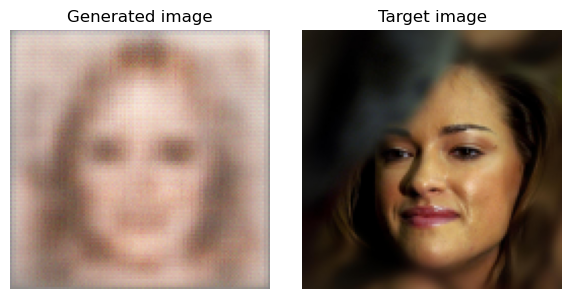

_o_Clock_Shadow
Arched_Eyebrows
Attractive
Bags_Under_Eyes
Bangs
Big_Lips
Big_Nose
Black_Hair
Blond_Hair
Blurry
Brown_Hair
Goatee
Gray_Hair
Heavy_Makeup
High_Cheekbones
Male
Mouth_Slightly_Open
Narrow_Eyes
No_Beard
Oval_Face
Pointy_Nose
Receding_Hairline
Rosy_Cheeks
Smiling 
Straight_Hair
Wavy_Hair
Wearing_Earrings
Wearing_Hat
Wearing_Lipstick
Wearing_Necklace
Young


In [17]:
target_index = 1

h_target = h[target_index, :]
# make tensor [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  
# h_target = torch.zeros(opt.h_dim).double().to(opt.device)
# h_target[1] = 1.0

# x_gen = net3(torch.mv(U, h_target)).detach().cpu().numpy().reshape(28, 28)
z = torch.mv(U, h_target)          # [z_dim]
z = z.unsqueeze(0)                 # [1, z_dim]  <-- add batch dim

x_gen = net3(z).detach().cpu().numpy()
x_gen = x_gen.reshape(3, 128, 128).transpose(1, 2, 0)

y_gen = net4(torch.mv(V, h_target)).detach().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].imshow(x_gen)
ax[0].set_title('Generated image')
ax[0].axis('off')

ax[1].imshow(data_im[target_index].numpy().transpose(1, 2, 0))
ax[1].set_title('Target image')
ax[1].axis('off')

plt.tight_layout()
plt.show()

for i, l in enumerate(y_gen):
    if l > 0:
        print(get_classes()[i])